# 0. Imports

In [19]:
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV # type: ignore

proj = ccrs.PlateCarree()

# 1. Data

In [2]:
DATA_DIR = "../data/"

LAT_LON = ["Lat", "Lon"]

In [3]:
#LPJ-GUESS output
lpj_df = pl.read_csv(DATA_DIR + "LPJ-GUESS_output_BERN1.csv")
lpj_df = lpj_df.rename({col: col + f"_lpj" for col in lpj_df.columns if not col in LAT_LON})
lpj_df

Lon,Lat,NPP_lpj,SoilR_lpj,MaxBiomeCmax_lpj,MaxBiomeLAI_lpj,VegC_lpj,LitterC_lpj,SoilC_lpj,Biome_Cmax_lpj,Biome_LAI_lpj,Biome_obs_lpj
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
39.75,-1.25,0.429,0.39,0.449,1.9821,1.225,0.758,5.941,8,12,12
150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
-63.75,82.75,0.0,0.0,0.0,0.0,0.0,0.003,0.002,13,13,17
59.25,30.75,0.043,0.042,0.09,0.2146,0.127,0.084,0.543,7,11,14
24.25,27.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,13,17
…,…,…,…,…,…,…,…,…,…,…,…
114.75,34.75,0.35,0.307,3.389,2.5025,3.502,1.763,3.537,5,5,5
12.25,52.25,0.507,0.425,6.303,3.3822,6.785,4.612,12.687,5,5,5
-154.25,61.75,0.013,0.01,0.014,0.0951,0.014,0.097,1.207,11,11,17


In [4]:
# Grid information
grid_df = pl.read_csv(DATA_DIR + "gridlist_pan_gfed_ISO3_UN_ecoregion.txt", separator=' ')
grid_df = grid_df.rename({col: col + f"_grid" for col in grid_df.columns if not col in LAT_LON})
grid_df

Lon,Lat,GFED-region_grid,Pan_2007_grid,ISO3_grid,UN_grid,Ecoregion_grid
f64,f64,i64,str,str,i64,i64
-69.75,-55.25,5,"""Americas""","""CHL""",152,4
-69.25,-55.25,5,"""Americas""","""CHL""",152,4
-71.25,-54.75,5,"""Americas""","""CHL""",152,4
-70.75,-54.75,5,"""Americas""","""CHL""",152,4
-70.25,-54.75,5,"""Americas""","""CHL""",152,4
…,…,…,…,…,…,…
-73.75,79.75,1,"""Canada""","""CAN""",124,11
-73.25,79.75,1,"""Canada""","""CAN""",124,11
-72.75,79.75,1,"""Canada""","""CAN""",124,11


In [5]:
# Soil texture
soil_df = pl.read_csv(DATA_DIR + "soilmap.dat", separator="\t")
soil_df = soil_df.drop_nans().rename({"lon": "Lon", "lat": "Lat"})
soil_df = soil_df.rename({col: col + f"_soil" for col in soil_df.columns if not col in LAT_LON})
soil_df

Lon,Lat,clay_soil,silt_soil,sand_soil,orgC_soil,CN_soil,pH_soil,cellfraction_soil
f64,f64,f64,f64,f64,f64,f64,f64,f64
-179.75,71.25,0.08,0.37,0.55,0.02,11.0,5.9,0.482
-179.75,68.75,0.2,0.48,0.32,0.031,17.0,6.3,0.753
-179.75,68.25,0.2,0.48,0.32,0.031,17.0,6.3,0.447
-179.75,67.75,0.2,0.48,0.32,0.031,17.0,6.3,0.526
-179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.422
…,…,…,…,…,…,…,…,…
179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.455
179.75,66.75,0.2,0.48,0.32,0.031,17.0,6.3,0.408
179.75,66.25,0.2,0.48,0.32,0.031,17.0,6.3,0.597


In [6]:
# Load all climate datafiles and put in one dictionary
climate_files = {
    "tswrf": "Tswrfdaymean1961_1990.csv",
    "pre": "Predaymean1961_1990.csv",
    "tmp": "Tmpdaymean1961_1990.csv",
    "tmax": "Tmaxdaymean1961_1990.csv",
    "tmin": "Tmindaymean1961_1990.csv"
}

climate_df = {}
for name, path in climate_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    climate_df[name] = df

# Load all climate statistics datafiles and put in one dictionary
stats_files = {
    "tswrf": "Tswrfdaymean1961_1990_stats.csv",
    "pre": "Predaymean1961_1990_stats.csv",
    "tmp": "Tmpdaymean1961_1990_stats.csv",
    "tmax": "Tmaxdaymean1961_1990_stats.csv",
    "tmin": "Tmindaymean1961_1990_stats.csv"}

stats_df = {}
for name, path in stats_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    stats_df[name] = df

In [7]:
# Merge all dataframes on Lat and Lon
merged_df = lpj_df.join(grid_df, on=LAT_LON, how="inner").join(soil_df, on=LAT_LON, how="inner")

for name, df in stats_df.items():
    merged_df = merged_df.join(df, on=LAT_LON, how="inner")

In [8]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open(DATA_DIR + "legend of biomes.txt", 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [9]:
def drop_ground_truth(df):
    """Drops Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe."""
    return df.select([col for col in df.columns if not col.endswith(("_lpj", "_grid")) and col not in ["Lat", "Lon"]])

# 2. Data Description and Visualization
In this phase, provide an overview of the distribution of the outcome variables and select a
few key features for visualization. Present these insights using graphical representations
and a summary table of measures. You can refer to the RandomForestDemo notebook for
inspiration.

In [10]:
#TODO

# 3. Binary Classification
In this part, you are going to build a binary classifier to classify two classes of biomes from
“Biome_obs”. You can choose one of the biomes and try to train a classifier that can distin-
guish this biome from the other data, e.g, ’Arctic/alpine tundra’ or ’not Arctic/alpine tundra’.
One way to narrow down the data if you have trouble creating the binary classifier is to
only include samples from two different country codes or regions.

In [123]:
arctic_str = "Arctic/alpine tundra"
arctic_index = biome_names.index(arctic_str) + 1

canada_df = merged_df.filter(pl.col("ISO3_grid") == "CAN")
russia_df = merged_df.filter(pl.col("ISO3_grid") == "RUS")

#### 3.1 Data Split
Split your dataset into two parts: a training set and a test set. The training set is used to
train the model, and the test set is used to evaluate model performance. Think through
how you split your data and what fits your purpose. Ways to split your data could be
through climate, zone, biome, countries or continents. Are all the biomes represented in
both your train and test data? Are the frequency of biome classes representative?

In [124]:
y_train = canada_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_train = drop_ground_truth(canada_df)

y_test = russia_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_test = drop_ground_truth(russia_df)

#### 3.2. Model training
Next, train a Random Forest binary classification model. You can start by using training
data from one smaller region (could be one country code). Evaluate your model and try to
optimise the hyperparameters.

In [125]:
bin_class = RandomForestClassifier(random_state=1, max_depth=5, n_estimators=100)
bin_class.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

#### 3.3. Model evaluation
Evaluate the model's performance using appropriate metrics for binary classification. Com-
mon metrics include precision, recall, and to plot the predictions in a confusion matrix. Test
the model trained on one part of the world on the same biome in another part of the world,
e.g., Arctic/alpine tundra in either North America or Siberia. Does the model show equal
skill in both areas? Could the features you have chosen affect the skill of the model in an-
other part of the world? Why?

In [126]:
score_train = bin_class.score(X_train, y_train)
score_test = bin_class.score(X_test, y_test)
print(f"Training score: {score_train:.4f}")
print(f"Test score: {score_test:.4f}")

Training score: 0.9718
Test score: 0.8419


In [127]:
print("\nClassification Report:")
print(classification_report(y_test, bin_class.predict(X_test), target_names=["Not Arctic", "Arctic"]))


Classification Report:
              precision    recall  f1-score   support

  Not Arctic       0.93      0.82      0.87      7810
      Arctic       0.71      0.88      0.79      3886

    accuracy                           0.84     11696
   macro avg       0.82      0.85      0.83     11696
weighted avg       0.86      0.84      0.85     11696



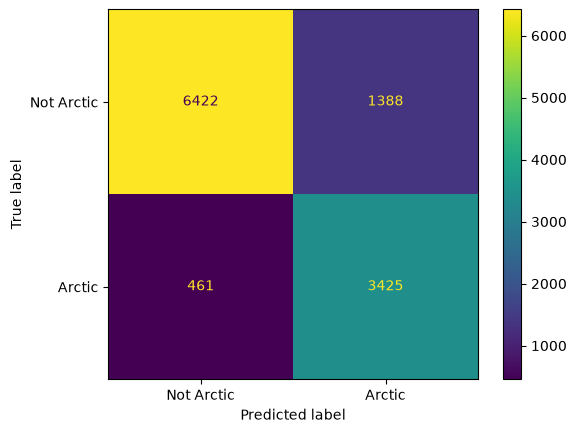

In [128]:
ConfusionMatrixDisplay.from_estimator(
    bin_class, X_test, y_test, display_labels=['Not Arctic', 'Arctic'], 
)
plt.show()

#### 3.4. Feature importance and model interpretation
Analyze which features played the most crucial role in your model's decisions. Finally, dis-
cuss and interpret your results comprehensively, and explore any misclassifications to gain
valuable insights into how well machine learning models adapt to different continents and
environments. Are all features that you used for training necessary? Could you reduce the
number of features used? Were there features that you did not use that could be im-
portant? Why would they be important?

Optional: Plot the misclassified regions on a world map.

In [129]:
feature_imp = pd.DataFrame(
    {'importance':bin_class.feature_importances_},
    index=X_train.columns)
feature_imp = feature_imp.sort_values(by='importance', ascending=False)
print("\nFeature Importances:")
print(feature_imp.head(60))


Feature Importances:
                    importance
FallMedian_tmp        0.104522
FallMedian_tmax       0.069130
FallMean_tmp          0.068300
SummerMedian_tmin     0.068095
FallMean_tmax         0.057021
SummerMedian_tmax     0.050376
SummerMean_tmin       0.048446
FallMean_tmin         0.039333
SummerMedian_tmp      0.037711
SpringStd_tmin        0.035169
SummerMean_tmax       0.033424
FallMean_tswrf        0.030777
SpringStd_tmp         0.027818
SummerMean_tmp        0.026613
SummerMean_tswrf      0.023701
SpringStd_tmax        0.019603
FallMedian_tmin       0.017840
SpringMedian_tswrf    0.015997
SpringMean_tmin       0.015910
FallMedian_tswrf      0.015532
WinterMean_tmin       0.015149
WinterMean_tmax       0.014813
WinterMedian_tswrf    0.013186
WinterMedian_tmin     0.012352
WinterMean_tmp        0.011762
SpringMean_tmp        0.010809
WinterMedian_tmax     0.010064
SummerStd_tmp         0.007598
WinterStd_tmax        0.007129
WinterStd_tswrf       0.006831
SummerMedian_tswr

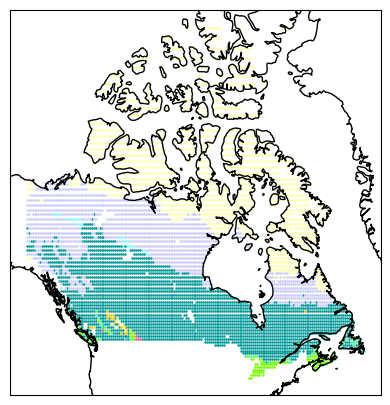

In [130]:
canada_mean_lon = canada_df.select(pl.col("Lon")).mean().item()
proj_canada = ccrs.Mercator(central_longitude=canada_mean_lon)

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_canada))

for i, name in enumerate(biome_names):
    biome = canada_df.filter(pl.col("Biome_obs_lpj") == i + 1)
    ax.scatter(biome.select(pl.col("Lon")).to_numpy().flatten(),
                biome.select(pl.col("Lat")).to_numpy().flatten(),
                color=biome_rgbs[i], s=.6, label=name, transform=proj)
ax.coastlines()

In [131]:
russia_mean_lon = russia_df.select(pl.col("Lon")).mean().item()
proj_russia = ccrs.Mercator(central_longitude=russia_mean_lon)

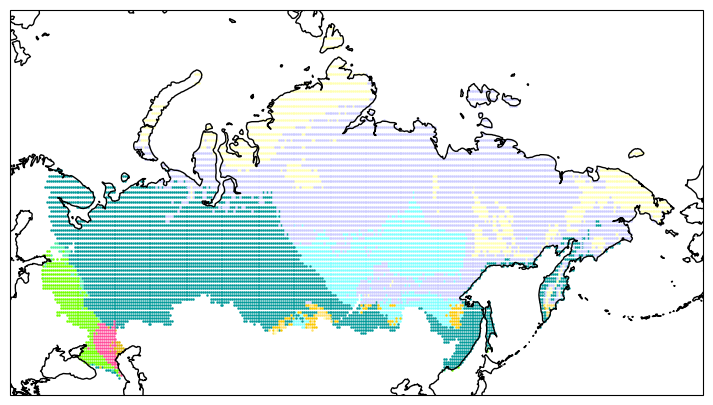

In [132]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

for i, name in enumerate(biome_names):
    biome = russia_df.filter(pl.col("Biome_obs_lpj") == i + 1)
    ax.scatter(biome.select(pl.col("Lon")).to_numpy().flatten(),
                biome.select(pl.col("Lat")).to_numpy().flatten(),
                color=biome_rgbs[i], s=.6, label=name, transform=proj)
ax.coastlines()

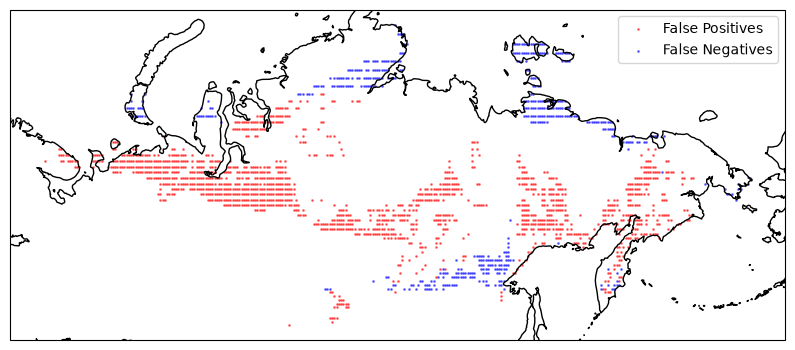

In [133]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

y_pred = bin_class.predict(X_test)
# plot lat/lon points where y_pred != y_test
fp = (y_pred == 1) & (y_test == 0)  # False Positives
fn = (y_pred == 0) & (y_test == 1)  #False Negatives
fp_df = russia_df.filter(fp)
fn_df = russia_df.filter(fn)

ax.scatter(fp_df.select(pl.col("Lon")).to_numpy().flatten(),
              fp_df.select(pl.col("Lat")).to_numpy().flatten(),
                color='red', s=1, alpha=0.5, transform=proj, label='False Positives')
ax.scatter(fn_df.select(pl.col("Lon")).to_numpy().flatten(),
              fn_df.select(pl.col("Lat")).to_numpy().flatten(),
                color='blue', s=1, alpha=0.5, transform=proj, label='False Negatives')

ax.coastlines()
ax.legend()

# 4. Multiclass classification
In this part, you are going to build two multiclass random forest classification models to
classify up to 18 biomes. You can use a combination of country code and region to build a
subset that you as a group would be interested in, e.g. South America, Europe, South-east
Asia et.c., again try to find another region where an interesting comparison can be made
and if your model are performing well on a different geographic region. For example boreal
Europe vs Canada, mainland USA (not including Alaska) vs. Australia or South America
vs. Africa. Important: Use “Biome_obs” as your target variable.

#### 4.1 Data split
Split your dataset into two parts: a training set, and a test set. The training set is used to
train the model, the validation set to tune hyperparameters, and the test set to evaluate
model performance.

In [134]:
west_df = merged_df.filter(pl.col("Lon") < 0)
east_df = merged_df.filter(pl.col("Lon") >= 0)

# extract Biome_obs_lpj as y_train for west_df
X_train = drop_ground_truth(west_df)
y_train = west_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32))

X_test = drop_ground_truth(east_df)
y_test = east_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32))

#### 4.2 Model training
Next, train a Random Forest classification model using training data, and then put the
model on the test data.

In [164]:
multi_class = RandomForestClassifier(random_state=1, max_depth=15, n_estimators=100, n_jobs=-1)
multi_class.fit(X_train, y_train.to_numpy().flatten())

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [165]:
# evaluate the model on the test set
score_train = multi_class.score(X_train, y_train.to_numpy().flatten())
score_test = multi_class.score(X_test, y_test.to_numpy().flatten())
print(f"Training score: {score_train:.4f}")
print(f"Test score: {score_test:.4f}")

Training score: 0.9890
Test score: 0.6321


In [166]:
print("\nClassification Report:")
target_names = [biome_names[i-1] for i in set(y_test.to_numpy().flatten())]
print(classification_report(y_test, multi_class.predict(X_test), target_names=target_names))


Classification Report:


                      precision    recall  f1-score   support

 Boreal decid forest       0.88      0.48      0.62      1338
  Boreal ever forest       0.77      0.84      0.80      5998
 Temp/boreal mix fo.       0.37      0.12      0.18       455
   Temp decid forest       0.81      0.75      0.78      2397
 Temp broad ever fo.       0.86      0.71      0.78      1377
   Temp mixed forest       0.50      0.07      0.13        54
  Trop season forest       0.51      0.55      0.53      1414
    Trop rain forest       0.82      0.91      0.86      2566
   Trop decid forest       0.60      0.45      0.51      1066
      Moist savannas       0.15      0.54      0.24       437
        Dry savannas       0.27      0.43      0.34      1678
      Tall grassland       0.00      0.00      0.00       210
       Dry grassland       0.42      0.23      0.30      1829
    Xeric wood/shrub       0.35      0.39      0.37      1223
   Arid shrub/steppe       0.57      0.28      0.37      2452
       

/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to